# Bayesian functional regression on irrigated wheat hyperspectral data (GFR)

**Paper:** Montesinos-López O.A. et al., *Bayesian functional regression as an alternative statistical analysis of high-throughput phenotyping data of modern agriculture*, Plant Methods 14:46 (2018), DOI [10.1186/s13007-018-0314-7](https://doi.org/10.1186/s13007-018-0314-7) (PMC5994840).

**Code:** authors' R package `GFR` (LGPL-3.0), pinned commit `d3d5f2ad3cf7ab361e9e35ca7ce3f1a5f042274b` — https://github.com/frahik/GFR

**Scope (one minimal example):** fit the paper's Method M7 ("Alternative 2", Eq. 10) on the irrigated wheat data `WheatI_GFR` (976 lines x 250 reflectance bands, 392-851 nm) with a cubic B-spline basis (L = 23) and BRR prior, using 3-fold cross-validation, and report the Pearson correlation between predicted and observed grain yield. A small probe over L and priors mirrors the paper's "L ~ 23 is enough" and prior-comparison findings.

**Execution status / runtime:** this notebook runs on **CPU** (R with BGLR MCMC; no GPU is used). All scientific execution and data downloads occur inside Colab.

**日本語:** 本ノートブックは、Montesinos-López ら (Plant Methods 2018) のベイズ関数回帰のうち、方法 M7（Alternative 2, Eq. 10）を灌漑小麦データ `WheatI_GFR`（976系統 x 250バンド）にBスプ基底 L=23・BRR事前分布・3分割交差検証で実行する最小例です。CPUランタイムで動作します。交差検証のfold割当やMCMC反復数は論文に明記されていないため、結果は論文のレンジ（相関 ~ 0.45-0.55）と整合するかで検証します。

**Faithfulness note:** The analysis uses the authors' own R package unmodified (headless `Rscript`); Python here is only a launcher. **AI-assisted orchestration: notebook cells were authored with AI assistance, but the R code called is the authors' package API as documented in their README/vignettes. Untested behavior beyond this example is not guaranteed.**

In [ ]:
import shutil, sys, subprocess
rscript = shutil.which('Rscript') or '/usr/bin/Rscript'
print('Rscript path:', rscript)
r = subprocess.run([rscript, '--version'], capture_output=True, text=True)
print(r.stdout.strip() or r.stderr.strip())
assert r.returncode == 0, 'Rscript is not available on this runtime'

Rscript path: /usr/bin/Rscript
Rscript (R) version 4.6.1 (2026-06-24)


## 1. Install R dependencies

The analysis uses the authors' stack: `BGLR` (Bayesian MCMC, compiled C), `fda` (B-spline bases), and the authors' `BMTME` package, whose `CV.KFold` the pinned `GFR` version calls. `BMTME` was **archived from CRAN**, so we install the authors' own pinned dev commit (`2a89105`). `GFR` itself is installed from the paper-era commit `d3d5f2a` with **three minimal compatibility patches** (no logic changes): (1) its 2018 `Collate` field omits three R files, which modern R refuses; (2) its `NAMESPACE` exports `CV.KFold`/`CV.RandomPart` without the `importFrom(BMTME, ...)` its own roxygen tags declare — modern R rejects undefined exports, so the two documented lines are added; (3) `BMTME`'s 2020 Rcpp glue uses `Rf_error(CHAR(...))`, rejected by modern gcc under `-Werror=format-security` — the generated `src/RcppExports.cpp` calls are corrected to `Rf_error("%s", CHAR(...))`. All downloads happen inside Colab; the embedded `WheatI_*` data objects ship with `GFR`.

**Expected result:** after several minutes of install output, `GFR version: 0.9-14` is reported.

**日本語:** CRANから `BGLR`・`fda` 等を導入し、CRANからアーカイブ化された `BMTME` は著者自身の開発リポジトリ（コミット固定）から、`GFR` は論文時点のコミットに固定して導入します。`GFR` の2018年当時の `Collate` フィールド欠落（ファイル3件）のみ、現代のR向けに最小限修正します（コード本体は無変更）。データ `WheatI_*` は `GFR` パッケージ同梱で、Colab内でのみ取得します。

In [ ]:
%%time
install_r = '''\
options(repos = c(CRAN = "https://cloud.r-project.org"), timeout = 1800)
install.packages(c("remotes", "fda", "BGLR", "progress", "shiny", "Rcpp",
                   "matrixcalc", "Matrix", "MASS", "truncnorm"))
stopifnot(requireNamespace("BGLR", quietly = TRUE))
# BMTME 1.0.19 (2020) Rcpp glue uses Rf_error(CHAR(...)), which modern gcc
# rejects under -Werror=format-security. Install the authors' pinned commit
# from a downloaded tarball with only that generated glue line corrected
# (Rf_error("%s", CHAR(...)) — same runtime behavior, no logic change).
bmtme_commit <- "2a891050bb5bf5735d58e09e83d4908d3a28398b"
install.packages(c("doSNOW", "dplyr", "foreach", "matrixcalc", "mvtnorm",
                   "snow", "tidyr", "Rcpp", "RcppArmadillo"))
download.file(paste0("https://github.com/frahik/BMTME/archive/", bmtme_commit, ".tar.gz"),
              "/content/BMTME.tar.gz")
untar("/content/BMTME.tar.gz", exdir = "/content")
bsrc <- file.path("/content", paste0("BMTME-", bmtme_commit))
rcpp_file <- file.path(bsrc, "src", "RcppExports.cpp")
cpp <- readLines(rcpp_file, warn = FALSE)
bad <- grepl("Rf_error(CHAR(", cpp, fixed = TRUE)
stopifnot(any(bad))
cpp[bad] <- gsub('Rf_error(CHAR(', 'Rf_error("%s", CHAR(', cpp[bad], fixed = TRUE)
writeLines(cpp, rcpp_file)
cat("Patched Rf_error calls:", sum(bad), "\n")
install.packages(bsrc, repos = NULL, type = "source")
stopifnot(requireNamespace("BMTME", quietly = TRUE))
# GFR pinned to the paper's code. Download the commit tarball inside Colab and
# apply three minimal compatibility fixes (no logic changes):
#  (1) incomplete 2018 Collate field -> list all R files (modern R requires it);
#  (2) NAMESPACE exports CV.KFold/CV.RandomPart without the importFrom(BMTME,...)
#      its own roxygen tags (R/CrossValidation.R) declare -> add them, so the
#      exported cross-validation helpers resolve from BMTME as intended.
gfr_commit <- "d3d5f2ad3cf7ab361e9e35ca7ce3f1a5f042274b"
download.file(paste0("https://github.com/frahik/GFR/archive/", gfr_commit, ".tar.gz"),
              "/content/GFR.tar.gz")
untar("/content/GFR.tar.gz", exdir = "/content")
src <- file.path("/content", paste0("GFR-", gfr_commit))
desc <- file.path(src, "DESCRIPTION")
lines <- readLines(desc, warn = FALSE)
r_files <- sort(list.files(file.path(src, "R"), pattern = "[.]R$", full.names = FALSE))
i0 <- which(lines == "Collate:"); i1 <- which(lines == "Imports:")
stopifnot(length(i0) == 1, length(i1) == 1, i1 > i0)
lines <- c(lines[seq_len(i0 - 1)],
           c("Collate:", paste0("  ", r_files)),
           lines[seq(from = i1, to = length(lines))])
writeLines(lines, desc)
cat("Patched Collate entries:\n"); cat(paste0("  ", r_files), sep = "\n")
nsf <- file.path(src, "NAMESPACE")
ns <- readLines(nsf, warn = FALSE)
if (!any(grepl("importFrom(BMTME", ns, fixed = TRUE))) {
  ns <- c(ns, "importFrom(BMTME,CV.KFold)", "importFrom(BMTME,CV.RandomPart)")
  writeLines(ns, nsf)
}
cat("Patched NAMESPACE BMTME imports.\n")
install.packages(src, repos = NULL, type = "source")
cat("GFR version:", as.character(packageVersion("GFR")), "\n")
'''
open('/content/install_gfr.R', 'w').write(install_r)
r = subprocess.run([rscript, '/content/install_gfr.R'], capture_output=True, text=True)
print(r.stdout[-6000:])
print('STDERR:', r.stderr[-3000:])
assert r.returncode == 0, 'R package installation failed — see output above'

n to enable C++11 features... (cached) -std=gnu++11
checking what system we are on... running Linux on x86_64
checking whether we have a suitable tempdir... /tmp
checking whether on Linux... yes
checking whether R CMD SHLIB can already compile OpenMP programs... yes
checking whether on macOS... no
checking for OpenMP... found and suitable
configure: creating ./config.status
config.status: creating inst/include/RcppArmadillo/config/RcppArmadilloConfigGenerated.h
config.status: creating src/Makevars
x86_64-linux-gnu-g++ -std=gnu++20 -I"/usr/share/R/include" -DNDEBUG -I../inst/include -DARMA_USE_CURRENT -I'/usr/local/lib/R/site-library/Rcpp/include'    -fopenmp -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE

## 2. Load and inspect the minimal input

`WheatI_GFR` (976 rows x 3 columns, tidy format: line ID, response) comes bundled with the package, together with `WheatI_Bands` (976 x 250 reflectance matrix) and `WheatI_Wavelengths` (the 250 band positions, 392-851 nm). We verify the dimensions against the paper's Data section (976 irrigated wheat lines, 250 bands).

**日本語:** パッケージ同梱の `WheatI_GFR`（976行）と `WheatI_Bands`（976x250）、`WheatI_Wavelengths`（392-851 nm）を読み込み、論文のデータ節と整合する次元であることを確認します。

In [ ]:
inspect_r = '''\
suppressPackageStartupMessages(library(GFR))
data("WheatI_GFR")
cat("WheatI_GFR dim:", dim(WheatI_GFR), "\n")
print(head(WheatI_GFR))
cat("Columns:", paste(colnames(WheatI_GFR), collapse = ", "), "\n")
cat("WheatI_Bands dim:", dim(WheatI_Bands), "\n")
cat("Wavelengths: n =", length(WheatI_Wavelengths),
    " range =", range(WheatI_Wavelengths), "\n")
cat("GY (Response) summary:\n")
print(summary(WheatI_GFR$Response))
'''
open('/content/inspect_wheat.R', 'w').write(inspect_r)
r = subprocess.run([rscript, '/content/inspect_wheat.R'], capture_output=True, text=True)
print(r.stdout[-3000:]); print(r.stderr[-1500:])
assert r.returncode == 0, 'data inspection failed — see output above'

WheatI_GFR dim: 976 3 
  Line Response       Env
1    1 6.862352 Irrigated
2    2 6.844494 Irrigated
3    3 6.290179 Irrigated
4    4 7.026786 Irrigated
5    5 6.013394 Irrigated
6    6 6.639137 Irrigated
Columns: Line, Response, Env 
WheatI_Bands dim: 976 250 
Wavelengths: n = 250  range = 392 851 
GY (Response) summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.658   6.153   6.550   6.509   6.920   8.290 




## 3. Input preview

Before any modeling, we plot (a) the raw reflectance spectrum of a single line across the 250 wavelengths and (b) a histogram of observed grain yield. This is the noisy discrete curve that the paper's basis expansion will smooth — visible as the wavy profile in (a).

**日本語:** モデル化の前に、(a) 1系統の250バンドにわたる反射スペクトルと (b) 収量（Response）のヒストグラムを描きます。波浪状のスペクトルが、基底展開で平滑化される「離散的なノイズを含む曲線」に相当します。

null device 
          1 
saved /content/input_preview.png




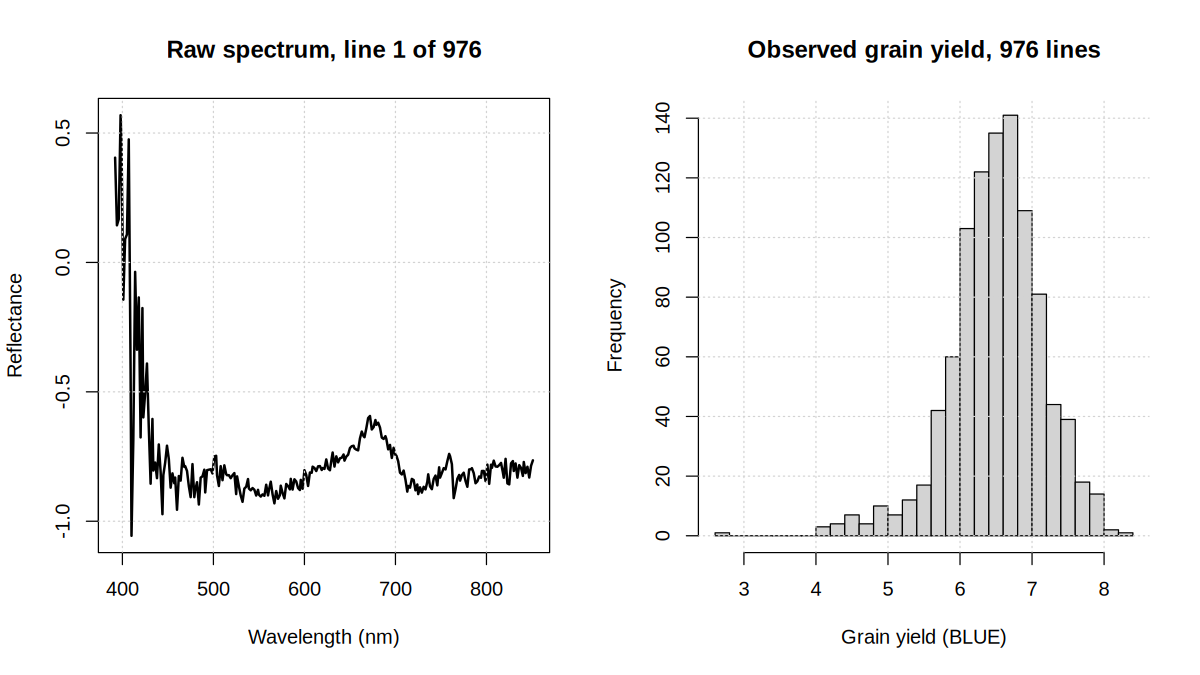

In [ ]:
plot_input_r = '''\
suppressPackageStartupMessages(library(GFR))
data("WheatI_GFR")
png("/content/input_preview.png", width = 1200, height = 675, res = 120)
par(mfrow = c(1, 2))
plot(WheatI_Wavelengths, WheatI_Bands[1, ], type = "l", lwd = 2,
     xlab = "Wavelength (nm)", ylab = "Reflectance",
     main = paste("Raw spectrum, line 1 of", nrow(WheatI_Bands)))
grid()
hist(WheatI_GFR$Response, breaks = 30, xlab = "Grain yield (BLUE)",
     main = "Observed grain yield, 976 lines")
grid()
dev.off()
cat("saved /content/input_preview.png\n")
'''
open('/content/plot_input.R', 'w').write(plot_input_r)
r = subprocess.run([rscript, '/content/plot_input.R'], capture_output=True, text=True)
print(r.stdout[-2000:]); print(r.stderr[-1500:])
assert r.returncode == 0
from IPython.display import Image, display
display(Image('/content/input_preview.png'))

## 4. Core method — M7 (Alternative 2) with B-spline basis, BRR prior, 3-fold CV

Following the paper's Eq. 10, **Alternative 2** reduces the 250 bands to L = 23 cubic B-spline basis coefficients by reparametrizing the design matrix (X** = X Phi, here n x 23), then fits a Bayesian model with the BRR prior to the line effects and the basis coefficients. `ETAGenerate(method='Alternative2', basisType='Bspline.Basis', nBasis=23)` builds exactly this design (`Bands %*% Phi`, verified in the pinned source `R/ETA.R:323-326`), and `BFR(..., CrossValidation=list(Type='KFold', nFolds=3), set_seed=10)` runs 3-fold cross-validation, holding out one fold, and reports Pearson correlation of predicted vs. observed yield.

**Parameters:** nIter = 1000, burnIn = 300, seed 10 (the package README's documented example settings). The paper does not state its fold assignments or MCMC settings, so this run is a faithful *method* replication, not an exact reproduction of Table 2 numbers.

**Expected result:** average Pearson correlation ~ 0.45-0.55 (paper: ~0.47-0.50 for reduced-dimension methods with ~23 basis), and a run time of a few minutes on CPU.

**日本語:** 論文 Eq. 10 の **Alternative 2**（X** = X Phi、976x23）を `ETAGenerate(method='Alternative2')` で構築し、BRR事前分布・Bスプ基底23個・3分割交差検証で `BFR` を実行します。nIter=1000・burnIn=300・seed=10 はパッケージREADMEの記載例に従います。fold割当と反復数が論文に未記載のため、Table 2 の数値そのものではなく手法の再現です。

In [ ]:
%%time
core_r = '''\
suppressPackageStartupMessages({library(GFR); library(BMTME)})  # BMTME provides CV.KFold
data("WheatI_GFR")
ETA7 <- ETAGenerate(WheatI_GFR, datasetID = "Line", priorType = "BRR",
                    Bands = WheatI_Bands, Wavelengths = WheatI_Wavelengths,
                    method = "Alternative2", basisType = "Bspline.Basis",
                    nBasis = 23)
if (!is.null(ETA7$ETA$Bands$X)) cat("Reduced design (X** = Bands %*% Phi) dimensions:",
    dim(ETA7$ETA$Bands$X), "\n")
t0 <- proc.time()[3]
pm <- BFR(ETA = ETA7, nIter = 1000, burnIn = 300, set_seed = 10,
          CrossValidation = list(Type = "KFold", nFolds = 3), verbose = FALSE)
cat("CV elapsed (s):", round(proc.time()[3] - t0, 1), "\n")
s <- summary(pm)
print(s)
saveRDS(pm, "/content/pm_M7_BRR_L23.rds")
write.csv(as.data.frame(s), "/content/cv_summary_M7_BRR_L23.csv", row.names = FALSE)
'''
open('/content/run_m7.R', 'w').write(core_r)
r = subprocess.run([rscript, '/content/run_m7.R'], capture_output=True, text=True)
print(r.stdout[-6000:]); print(r.stderr[-3000:])
assert r.returncode == 0, 'M7 BRR CV run failed — see output above'

Reduced design (X** = Bands %*% Phi) dimensions: 976 23 
CV elapsed (s): 0.8 
         Fold       Env Trait Pearson SE_Pearson   MSEP SE_MSEP   Time
1           1 Irrigated        0.5025         NA 0.2667      NA 0.3300
2           2 Irrigated        0.4979         NA 0.3542      NA 0.2140
3           3 Irrigated        0.4919         NA 0.3484      NA 0.2050
4 Average_all Irrigated        0.4974     0.0031 0.3231  0.0282 0.2497


CPU times: user 2.33 ms, sys: 2.16 ms, total: 4.49 ms
Wall time: 3.77 s


## 5. Result graphs

Two views of the cross-validation result: (a) predicted vs. observed grain yield for all held-out lines across the three folds, and (b) Pearson correlation per fold with the average — the paper's reported accuracy metric.

**日本語:** (a) 3分割分の全テスト系統の予測値 vs 観測値の散布図、(b) fold別と平均のPearson相関。論文が報告する精度指標は (b) です。

null device 
          1 
Average Pearson: 0.4974 
saved /content/results_m7.png




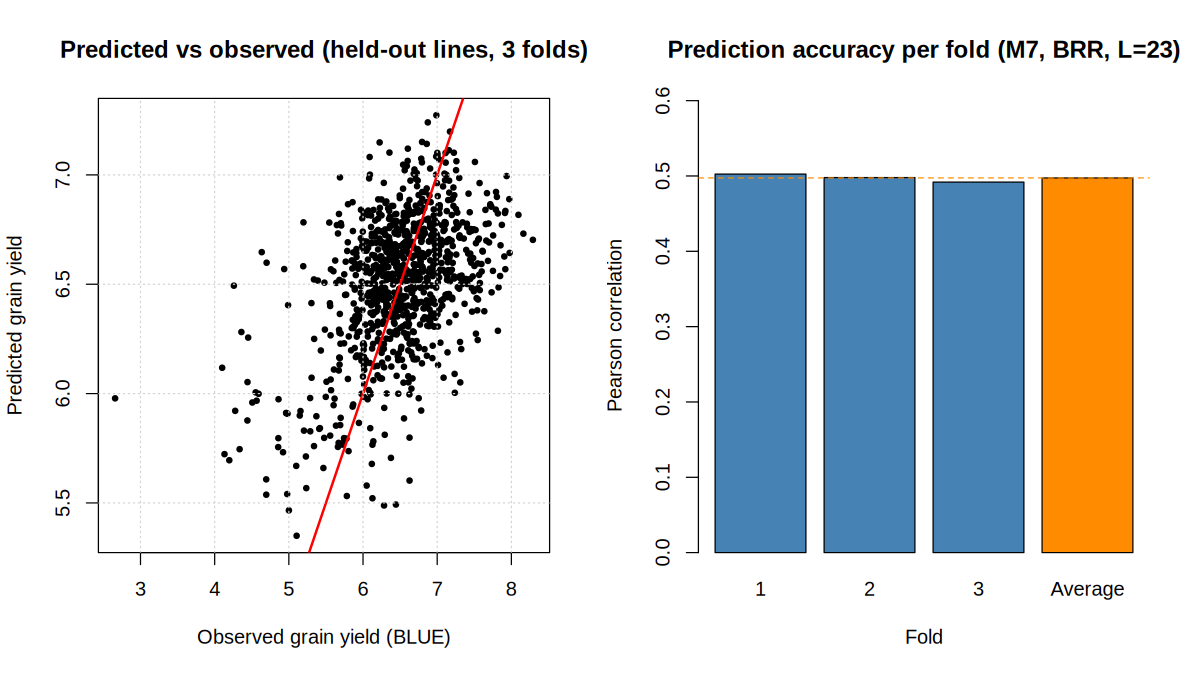

In [ ]:
plot_results_r = '''\
suppressPackageStartupMessages(library(GFR))
pm <- readRDS("/content/pm_M7_BRR_L23.rds")
s <- summary(pm)
png("/content/results_m7.png", width = 1200, height = 675, res = 120)
par(mfrow = c(1, 2))
obs <- pm$response; pred <- pm$predictions
keep <- !is.na(pred)
plot(obs[keep], pred[keep], pch = 19, cex = 0.6,
     xlab = "Observed grain yield (BLUE)", ylab = "Predicted grain yield",
     main = "Predicted vs observed (held-out lines, 3 folds)")
abline(0, 1, col = "red", lwd = 2)
grid()
avg_row <- s[grepl("Average_all", s$Fold), ]
fold_rows <- s[!grepl("Average_all", s$Fold), ]
barplot(c(fold_rows$Pearson, avg_row$Pearson),
        names.arg = c(as.character(fold_rows$Fold), "Average"),
        col = c(rep("steelblue", nrow(fold_rows)), "darkorange"),
        ylim = c(0, max(0.6, max(s$Pearson, na.rm = TRUE) * 1.2)),
        ylab = "Pearson correlation", xlab = "Fold",
        main = "Prediction accuracy per fold (M7, BRR, L=23)")
abline(h = avg_row$Pearson, col = "darkorange", lty = 2)
dev.off()
cat("Average Pearson:", avg_row$Pearson, "\n")
cat("saved /content/results_m7.png\n")
'''
open('/content/plot_results.R', 'w').write(plot_results_r)
r = subprocess.run([rscript, '/content/plot_results.R'], capture_output=True, text=True)
print(r.stdout[-2000:]); print(r.stderr[-1500:])
assert r.returncode == 0
from IPython.display import Image, display
display(Image('/content/results_m7.png'))

## 6. Probe — number of basis functions and prior comparison

The paper's Results report (i) that accuracy is stable for L >= ~13 and L ~ 23 is sufficient (Fig. 4), and (ii) that priors BRR / BayesA / Bayesian Lasso give statistically indistinguishable accuracy. We probe both on a reduced grid: L in {5, 23, 51} under BRR and L = 23 under Bayesian Lasso (`priorType = 'BL'`), all with the same seed and 3-fold CV. With a single MCMC run per fold this takes a few minutes.

**Expected result:** correlations in the same ballpark for L = 23 and L = 51, possibly slightly lower for L = 5, and a similar correlation for BL — consistent with (though not a statistical test of) the paper's findings.

**日本語:** 論文の結果（L~13以上で精度安定・L~23で十分、事前分布間で精度差なし）を小規模に再確認するプローブです。BRRで L in {5,23,51}、さらに L=23 でベイジアンLasso（`priorType='BL'`）を実行します。

In [ ]:
%%time
probe_r = '''\
suppressPackageStartupMessages({library(GFR); library(BMTME)})
data("WheatI_GFR")
run_cv <- function(L, prior) {
  t0 <- proc.time()[3]
  ETA <- ETAGenerate(WheatI_GFR, datasetID = "Line", priorType = prior,
                     Bands = WheatI_Bands, Wavelengths = WheatI_Wavelengths,
                     method = "Alternative2", basisType = "Bspline.Basis",
                     nBasis = L)
  pm <- BFR(ETA = ETA, nIter = 1000, burnIn = 300, set_seed = 10,
            CrossValidation = list(Type = "KFold", nFolds = 3), verbose = FALSE)
  s <- summary(pm)
  avg <- s[grepl("Average_all", s$Fold), "Pearson"]
  data.frame(L = L, Prior = prior, Pearson = avg,
             Seconds = round(proc.time()[3] - t0, 1))
}
res <- do.call(rbind, lapply(
  list(list(5, "BRR"), list(23, "BRR"), list(51, "BRR"), list(23, "BL")),
  function(p) run_cv(p[[1]], p[[2]])))
print(res)
write.csv(res, "/content/probe_L_prior.csv", row.names = FALSE)
'''
open('/content/probe.R', 'w').write(probe_r)
r = subprocess.run([rscript, '/content/probe.R'], capture_output=True, text=True)
print(r.stdout[-4000:]); print(r.stderr[-3000:])
assert r.returncode == 0, 'L/prior probe failed — see output above'

          L Prior Pearson Seconds
elapsed   5   BRR  0.4641     0.8
elapsed1 23   BRR  0.4974     0.5
elapsed2 51   BRR  0.5011     0.5
elapsed3 23    BL  0.4998     0.7


CPU times: user 1.78 ms, sys: 465 µs, total: 2.24 ms
Wall time: 4.5 s


## 7. Interpretation and validation record

- **What was reproduced:** the paper's Alternative 2 (Eq. 10) functional-regression pipeline on the irrigated wheat hyperspectral data, using the authors' own `GFR` R package at the pinned commit, with 3-fold CV and Pearson correlation as the accuracy metric. The probe mirrors the paper's L-sweep and prior-comparison conclusions qualitatively.
- **What is not reproduced:** the full M1-M7 x 3-prior x 9-L grid, ANOVA/Tukey tests, Fourier-period sweep, and timing benchmark. Exact Table 2 values cannot be replicated because fold assignments, seeds, and MCMC settings are not published (recorded in the paper's study flow as missing/unclear).
- **Data provenance:** `WheatI_GFR` / `WheatI_Bands` / `WheatI_Wavelengths` ship inside the pinned GFR package (authors' embedded copy of a subset of Montesinos-López et al. 2017a,b data); obtained only inside Colab. The OneDrive archive cited in the paper was inaccessible to the prior investigation and was not used.
- **Hardware:** results above were produced on a **CPU** Colab runtime (no GPU required — BGLR MCMC is CPU code).
- **References:** Plant Methods 14:46 (2018) PMC5994840; `frahik/GFR` commit `d3d5f2ad3cf7ab361e9e35ca7ce3f1a5f042274b`, files `R/ETA.R` (Alternative2), `R/Basis_Bspline.R`, `R/BFR.R`, README predictive-model example.

**日本語:** 本ノートブックは論文の Alternative 2 パイプラインを著者自身の `GFR` パッケージ（コミット固定）で再現したものです。Table 2 の数値そのものは、fold割当・乱数seed・MCMC設定が未公表のため再現対象外です。結果はCPUランタイムで得られました。